# Cybersecurity Logistic Regression and Feature Scaling

**Author:** Usha Priya Krishnasamy  
**Project Type:** Logistic regression, feature scaling, hyperparameter tuning, and classification evaluation  
**Datasets:** BETH Honeypot, Cybersecurity Attacks Dataset, and UNSW-NB15

The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.
#### Project Overview

This notebook applies logistic regression to three cybersecurity datasets used for threat detection, anomaly analysis, and attack classification.

The workflow compares standardized and normalized feature scaling, applies cross-validated logistic regression, and evaluates classification performance using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves.

This notebook is included in the modeling folder because it focuses on classification modeling and feature-scaling comparison.
#### Note

The raw datasets are not included in this repository. The analysis was developed using public cybersecurity datasets.

Logistic regression is used as an interpretable classification baseline before comparing more complex models such as SVM, random forest, gradient boosting, and anomaly detection methods.

In [1]:

## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

  
#########  Linraies for Logistic Regression regression
 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, mean_squared_error

random_state = 0
 


## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\32
['cybersecurity_attacks.csv', 'README.md']


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_logistic_regression_tuned(X_train, X_test, y_train, y_test, dataset_name, scaling_type):
    """
    Logistic Regression with hyperparameter tuning and cross-validation.
    Prevents overfitting using regularization and CV.
    """
    
    # Define parameter grid for hyperparameter tuning
    param_grid = {
        'C': [0.01, 0.1, 1, 10],       # Regularization strength
        'penalty': ['l2'],             # L2 regularization
        'solver': ['lbfgs']            # Suitable for L2 and multi-class
    }
    
    # Stratified K-Fold for better CV (preserves class balance)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    
    # GridSearchCV for tuning
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=0),
        param_grid,
        cv=cv_strategy,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    # Fit model
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    
    # Predict
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]  # For ROC-AUC
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n{dataset_name} ({scaling_type} features) - Logistic Regression (Tuned)")
    print(f"Best Hyperparameters: {grid.best_params_}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"{dataset_name} ({scaling_type}) - Confusion Matrix")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{dataset_name} ({scaling_type})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name} ({scaling_type})")
    plt.legend()
    plt.show()
    
    return best_model


# 1. BETH dataset
 

In [3]:


# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)
 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')



BETH (Standardized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.9988 | Precision: 0.9988 | Recall: 0.9988 | F1: 0.9988 | ROC-AUC: 0.9999


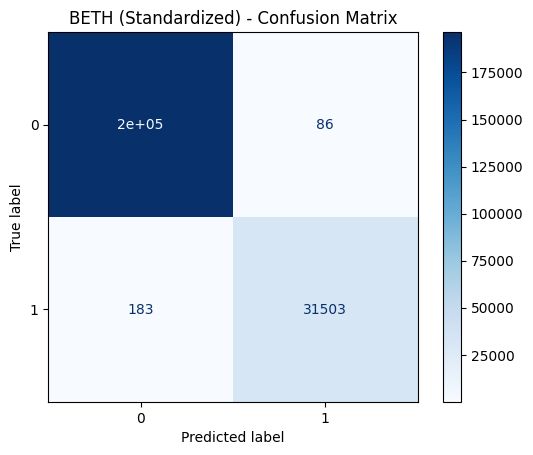

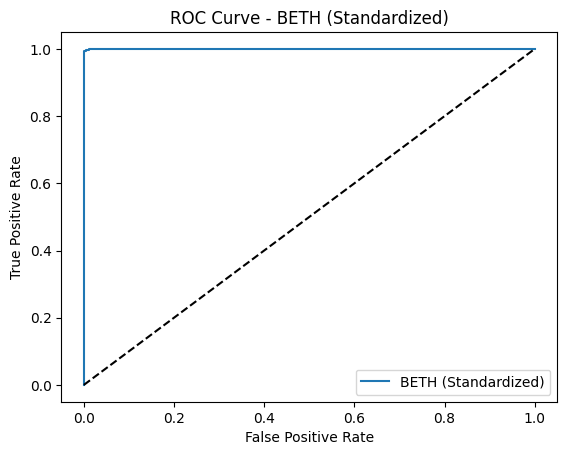


BETH (Normalized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.9988 | Precision: 0.9988 | Recall: 0.9988 | F1: 0.9988 | ROC-AUC: 0.9999


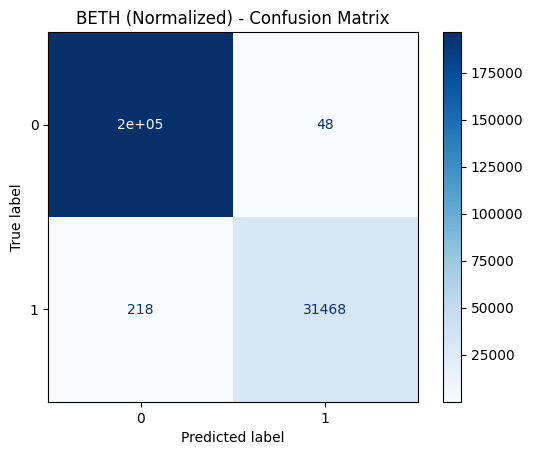

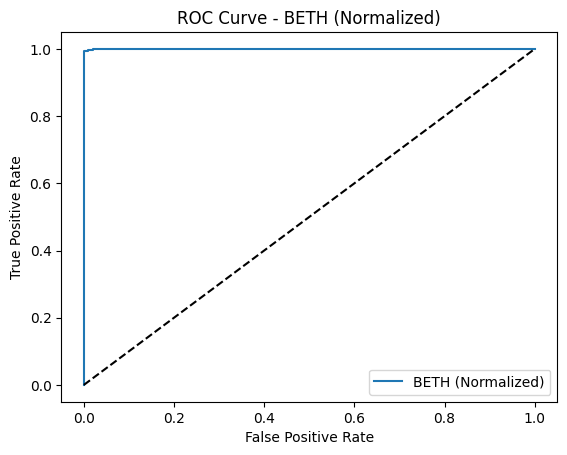

BETH Dataset Classification Results
                               Model  Accuracy  F1 Score
0  Logistic Regression (Regularized)  0.998821  0.998821
1   Logistic Regression (Normalized)  0.998834  0.998833


In [4]:

beth_model_reg = evaluate_logistic_regression_tuned(
    X_train_beth_reg, X_test_beth_reg, y_train_beth, y_test_beth, "BETH", "Standardized"
)

beth_model_norm = evaluate_logistic_regression_tuned(
    X_train_beth_norm, X_test_beth_norm, y_train_beth, y_test_beth, "BETH", "Normalized"
)

# Get predictions for final results table
y_pred_beth_reg = beth_model_reg.predict(X_test_beth_reg)
y_pred_beth_norm = beth_model_norm.predict(X_test_beth_norm)

# -----------------------------
# BETH Dataset Results
# -----------------------------
beth_results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Regularized)',
        'Logistic Regression (Normalized)',
    ],
    'Accuracy': [
        accuracy_score(y_test_beth, y_pred_beth_reg),
        accuracy_score(y_test_beth, y_pred_beth_norm),
    ],
    'F1 Score': [
        f1_score(y_test_beth, y_pred_beth_reg, average='weighted'),
        f1_score(y_test_beth, y_pred_beth_norm, average='weighted'),
    ]
})

print("BETH Dataset Classification Results")
print(beth_results)


#### BETH Dataset Findings

Logistic regression performed very strongly on the BETH dataset using both standardized and normalized features.

Both scaling methods produced high accuracy, F1-score, and ROC-AUC, showing that host-level features such as process, user, host, event, and namespace-related variables contain strong signal for detecting malicious activity.

The normalized model performed slightly better than the standardized model in this run, although the difference was very small.

Because cybersecurity datasets can be imbalanced, accuracy alone should not be used as the only metric. F1-score, recall, ROC-AUC, and confusion matrices provide a more complete evaluation.

# 2.Cybersecurity Attacks dataset

In [5]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 70
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
# Standardize features
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)



#### Target Engineering Note

The Cybersecurity Attacks dataset contains `Anomaly Scores`, which are continuous. For logistic regression, the scores are converted into a binary target.

Records with anomaly scores greater than 70 are treated as high-anomaly records. This threshold is used for baseline classification only and should be interpreted carefully.


CSA (Standardized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.6973 | Precision: 0.4862 | Recall: 0.6973 | F1: 0.5729 | ROC-AUC: 0.4998


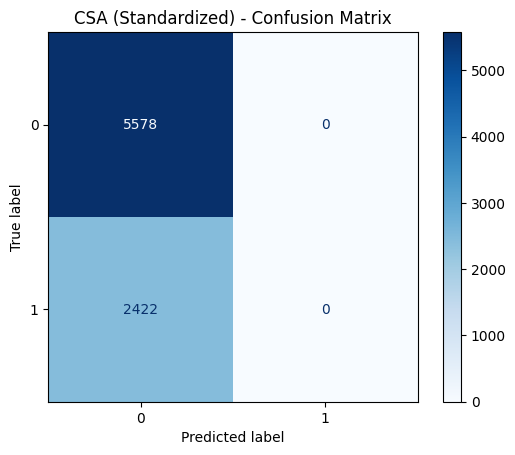

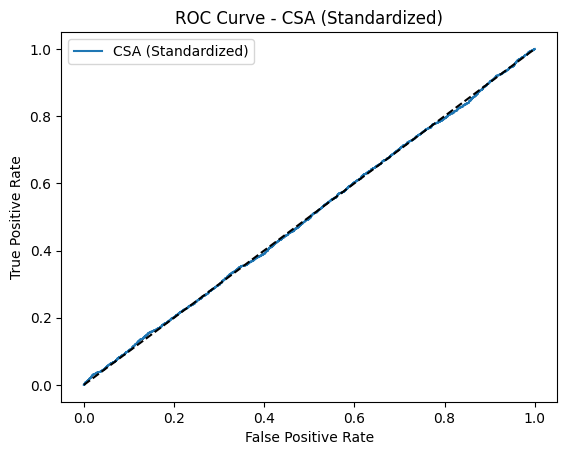


CSA (Normalized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.6973 | Precision: 0.4862 | Recall: 0.6973 | F1: 0.5729 | ROC-AUC: 0.4998


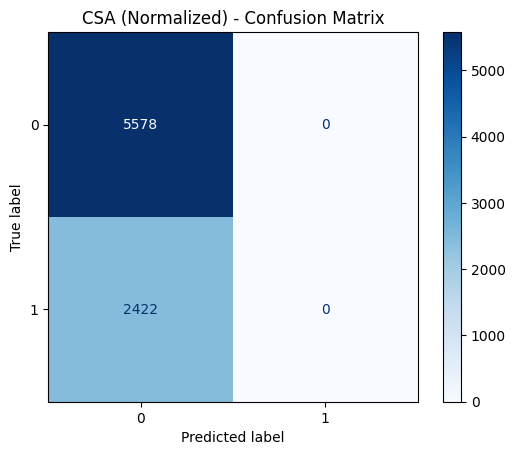

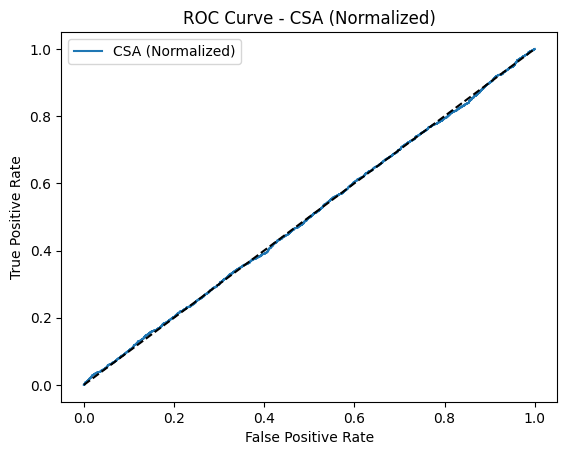


CSA Dataset Classification Results
                                Model  Accuracy  F1 Score
0  Logistic Regression (Standardized)   0.69725  0.572877
1    Logistic Regression (Normalized)   0.69725  0.572877


In [6]:
# ------------------------------
# Train Logistic Regression Models
# ------------------------------
csa_model_reg = evaluate_logistic_regression_tuned(
    X_train_csa_reg, X_test_csa_reg, y_train_csa, y_test_csa, "CSA", "Standardized"
)

csa_model_norm = evaluate_logistic_regression_tuned(
    X_train_norm_csa, X_test_norm_csa, y_train_csa, y_test_csa, "CSA", "Normalized"
)

# Get predictions for final results table
y_pred_csa_reg = csa_model_reg.predict(X_test_csa_reg)
y_pred_csa_norm = csa_model_norm.predict(X_test_norm_csa)

# -----------------------------
# CSA Dataset Results
# -----------------------------
csa_results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Standardized)',
        'Logistic Regression (Normalized)',
    ],
    'Accuracy': [
        accuracy_score(y_test_csa, y_pred_csa_reg),
        accuracy_score(y_test_csa, y_pred_csa_norm),
    ],
    'F1 Score': [
        f1_score(y_test_csa, y_pred_csa_reg, average='weighted'),
        f1_score(y_test_csa, y_pred_csa_norm, average='weighted'),
    ]
})

print("\nCSA Dataset Classification Results")
print(csa_results)


#### Cybersecurity Attacks Dataset Findings

The Cybersecurity Attacks dataset required target engineering because `Anomaly Scores` are continuous.

After converting anomaly scores into a binary high-anomaly target, logistic regression was used as a baseline classifier.

The CSA results should be interpreted carefully. High accuracy can be misleading when one class dominates the target distribution. ROC-AUC and confusion matrices are more important for understanding whether the model actually separates high-anomaly and low-anomaly records.

Overall, CSA is useful for testing the classification pipeline, but it is weaker than BETH and UNSW-NB15 for final cybersecurity model evaluation.

# 3.UNSW-NB15 Intrusion Detection dataset

In [7]:
unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'label' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)



Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')



UNSW (Standardized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.9427 | Precision: 0.9436 | Recall: 0.9427 | F1: 0.9429 | ROC-AUC: 0.9708


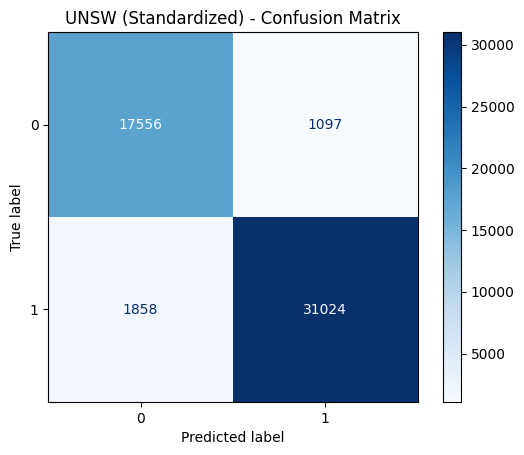

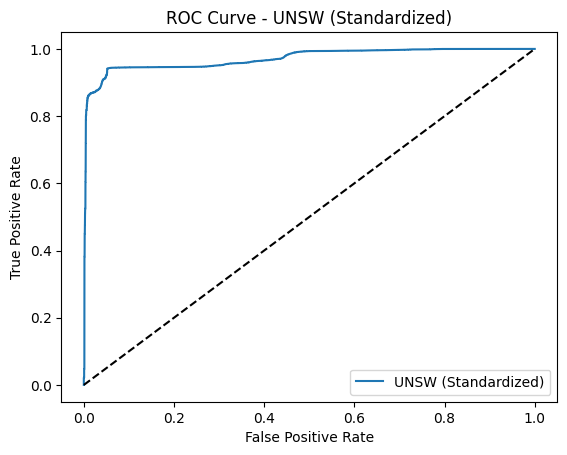


UNSW (Normalized features) - Logistic Regression (Tuned)
Best Hyperparameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.9448 | Precision: 0.9458 | Recall: 0.9448 | F1: 0.9450 | ROC-AUC: 0.9694


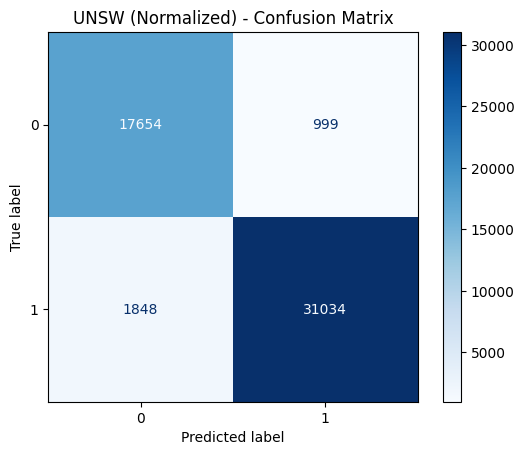

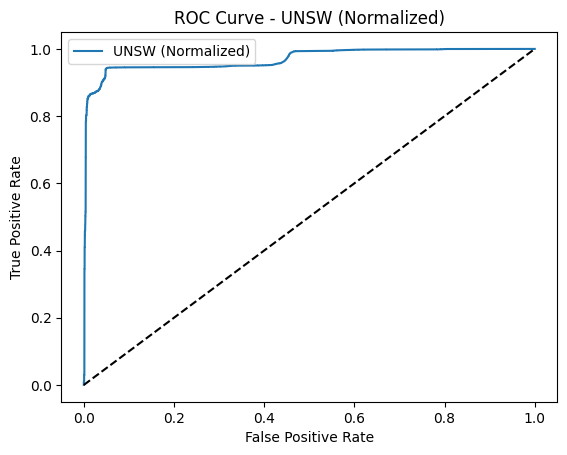


UNSW Dataset Classification Results
                                Model  Accuracy  F1 Score
0  Logistic Regression (Standardized)  0.942660  0.942898
1    Logistic Regression (Normalized)  0.944756  0.945009


In [8]:
# Logistic Regression - Standardized
unsw_model_reg = evaluate_logistic_regression_tuned(
    X_train_unsw_reg, X_test_unsw_reg, y_train, y_test, "UNSW", "Standardized"
)
y_pred_unsw_reg = unsw_model_reg.predict(X_test_unsw_reg)

# Logistic Regression - Normalized
unsw_model_norm = evaluate_logistic_regression_tuned(
    X_train_norm_unsw, X_test_norm_unsw, y_train, y_test, "UNSW", "Normalized"
)
y_pred_unsw_norm = unsw_model_norm.predict(X_test_norm_unsw)

# -----------------------------
# UNSW Dataset Results
# -----------------------------
unsw_results = pd.DataFrame({
    'Model': [
        'Logistic Regression (Standardized)',
        'Logistic Regression (Normalized)',
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_unsw_reg),
        accuracy_score(y_test, y_pred_unsw_norm),
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_unsw_reg, average='weighted'),
        f1_score(y_test, y_pred_unsw_norm, average='weighted'),
    ]
})

print("\nUNSW Dataset Classification Results")
print(unsw_results)


In [9]:
# -----------------------------
# Combined Results for Easy Comparison
# -----------------------------
combined_results = pd.DataFrame({
    'Dataset': ['BETH', 'CSA', 'UNSW']*2,
    'Feature Scaling': ['Standardized']*3 + ['Normalized']*3,
    'Accuracy': [
        accuracy_score(y_test_beth, y_pred_beth_reg),
        accuracy_score(y_test_csa, y_pred_csa_reg),
        accuracy_score(y_test, y_pred_unsw_reg),
        accuracy_score(y_test_beth, y_pred_beth_norm),
        accuracy_score(y_test_csa, y_pred_csa_norm),
        accuracy_score(y_test, y_pred_unsw_norm),
    ],
    'F1 Score': [
        f1_score(y_test_beth, y_pred_beth_reg, average='weighted'),
        f1_score(y_test_csa, y_pred_csa_reg, average='weighted'),
        f1_score(y_test, y_pred_unsw_reg, average='weighted'),
        f1_score(y_test_beth, y_pred_beth_norm, average='weighted'),
        f1_score(y_test_csa, y_pred_csa_norm, average='weighted'),
        f1_score(y_test, y_pred_unsw_norm, average='weighted'),
    ]
})

print("\nCombined Classification Results")
print(combined_results)


Combined Classification Results
  Dataset Feature Scaling  Accuracy  F1 Score
0    BETH    Standardized  0.998821  0.998821
1     CSA    Standardized  0.697250  0.572877
2    UNSW    Standardized  0.942660  0.942898
3    BETH      Normalized  0.998834  0.998833
4     CSA      Normalized  0.697250  0.572877
5    UNSW      Normalized  0.944756  0.945009


C:\Users\phxlab\AppData\Local\Temp\ipykernel_2772\151748485.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.fig.legend(title='Dataset', loc='upper right')


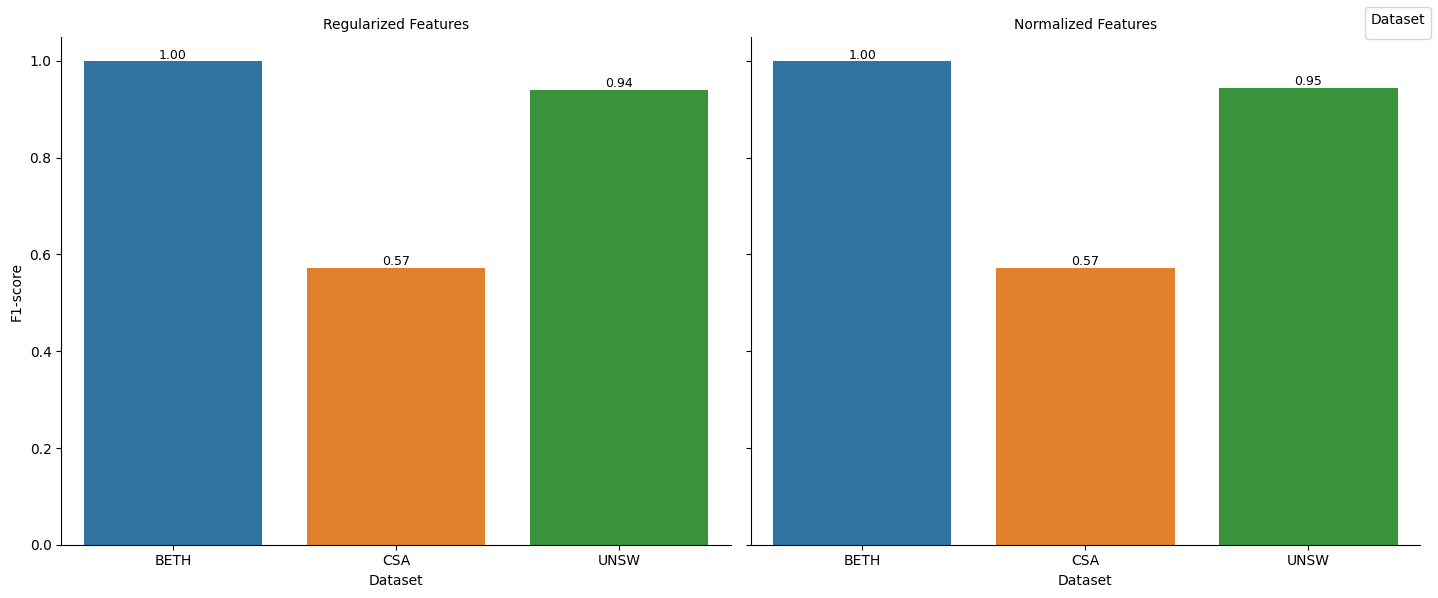

In [10]:
# Function to compute F1-score
def compute_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average='weighted')

# -------------------------------
# Predictions for each dataset
# -------------------------------
def get_preds(X_train, X_test, y_train):
    model = LogisticRegression(max_iter=500, random_state=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred

# BETH
y_pred_beth_reg = get_preds(X_train_beth_reg, X_test_beth_reg, y_train_beth)
y_pred_beth_norm = get_preds(X_train_beth_norm, X_test_beth_norm, y_train_beth)

# CSA
y_pred_csa_reg = get_preds(X_train_csa_reg, X_test_csa_reg, y_train_csa)
y_pred_csa_norm = get_preds(X_train_norm_csa, X_test_norm_csa, y_train_csa)

# UNSW
y_pred_unsw_reg = get_preds(X_train_unsw_reg, X_test_unsw_reg, y_train)
y_pred_unsw_norm = get_preds(X_train_norm_unsw, X_test_norm_unsw, y_train)

# -------------------------------
# F1-score DataFrame
# -------------------------------
results_f1 = pd.DataFrame({
    'Dataset': ['BETH', 'CSA', 'UNSW'] * 2,
    'Metric': ['F1-score'] * 6,
    'Value': [
        compute_f1(y_test_beth, y_pred_beth_reg),
        compute_f1(y_test_csa, y_pred_csa_reg),
        compute_f1(y_test, y_pred_unsw_reg),
        compute_f1(y_test_beth, y_pred_beth_norm),
        compute_f1(y_test_csa, y_pred_csa_norm),
        compute_f1(y_test, y_pred_unsw_norm)
    ],
    'Type': ['Regularized'] * 3 + ['Normalized'] * 3
})

# -------------------------------
# Plot F1-score only
# -------------------------------
def plot_metric(results_df, metric_name):
    g = sns.catplot(
        data=results_df,
        x='Dataset',
        y='Value',
        hue='Dataset',
        col='Type',
        kind='bar',
        height=6,
        aspect=1.2,
        dodge=False
    )
    g.set_titles("{col_name} Features")
    g.set_axis_labels('Dataset', metric_name)
    
    # Add a legend safely
    if g._legend is not None:
        g._legend.set_title('Dataset')
    else:
        g.fig.legend(title='Dataset', loc='upper right')

    # Add bar labels
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.2f', label_type='edge', fontsize=9)

    plt.tight_layout()
    plt.show()

# Plot F1-score
plot_metric(results_f1, 'F1-score')


#### UNSW-NB15 Dataset Findings

Logistic regression performed well on the UNSW-NB15 dataset.

Both standardized and normalized features produced strong classification results, with normalized features performing slightly better in this run.

The results show that network-flow features such as packet counts, byte counts, protocol, service, connection state, and attack-category-related variables provide useful signal for intrusion detection.

UNSW-NB15 is one of the stronger datasets in this project for network-level attack classification.

#### Overall Logistic Regression Conclusion

Across the three cybersecurity datasets, logistic regression provided a useful and interpretable classification baseline.

BETH produced the strongest performance, showing that host-level process, user, event, host, and namespace features are highly useful for detecting malicious activity.

UNSW-NB15 also performed strongly, especially after feature scaling, confirming that network-flow features are useful for intrusion detection.

The Cybersecurity Attacks dataset should be interpreted more cautiously because target engineering and class imbalance can make accuracy misleading.

Overall, this notebook shows that feature scaling is important for logistic regression and that classification metrics such as recall, F1-score, ROC-AUC, and confusion matrices are more informative than accuracy alone for cybersecurity threat detection.